# GHZ States Tutorial

## Introduction to GHZ States

The GHZ (Greenberger-Horne-Zeilinger) state is a maximally entangled quantum state involving three or more qubits. Named after physicists Daniel Greenberger, Michael Horne, and Anton Zeilinger, it represents one of the most fascinating examples of quantum entanglement.

### Mathematical Representation

For n qubits, the GHZ state is:

**|GHZ_n⟩ = (|00...0⟩ + |11...1⟩)/√2**

Examples:
- 3 qubits: **|GHZ₃⟩ = (|000⟩ + |111⟩)/√2**
- 4 qubits: **|GHZ₄⟩ = (|0000⟩ + |1111⟩)/√2**
- 5 qubits: **|GHZ₅⟩ = (|00000⟩ + |11111⟩)/√2**

### Key Properties

1. **Maximal Entanglement**: All qubits are maximally entangled with each other
2. **Correlated Outcomes**: All qubits always measure the same value (all 0s or all 1s)
3. **Quantum Non-locality**: Demonstrates stronger violations of local realism than Bell states
4. **Fragility**: Loss of any single qubit destroys the entanglement (unlike W states)

## Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## Part 1: Creating a Basic GHZ State

Let's start by creating a 4-qubit GHZ state to understand the circuit construction.

### Circuit Construction

The GHZ circuit uses:
1. **Hadamard (H) gate** on the first qubit: Creates superposition (|0⟩ + |1⟩)/√2
2. **Chain of CNOT gates**: Entangles all remaining qubits sequentially

For a 4-qubit GHZ state:
```
q0: ─H─●─────────[M]
       │
q1: ───X─●───────[M]
         │
q2: ─────X─●─────[M]
           │
q3: ───────X─────[M]
```

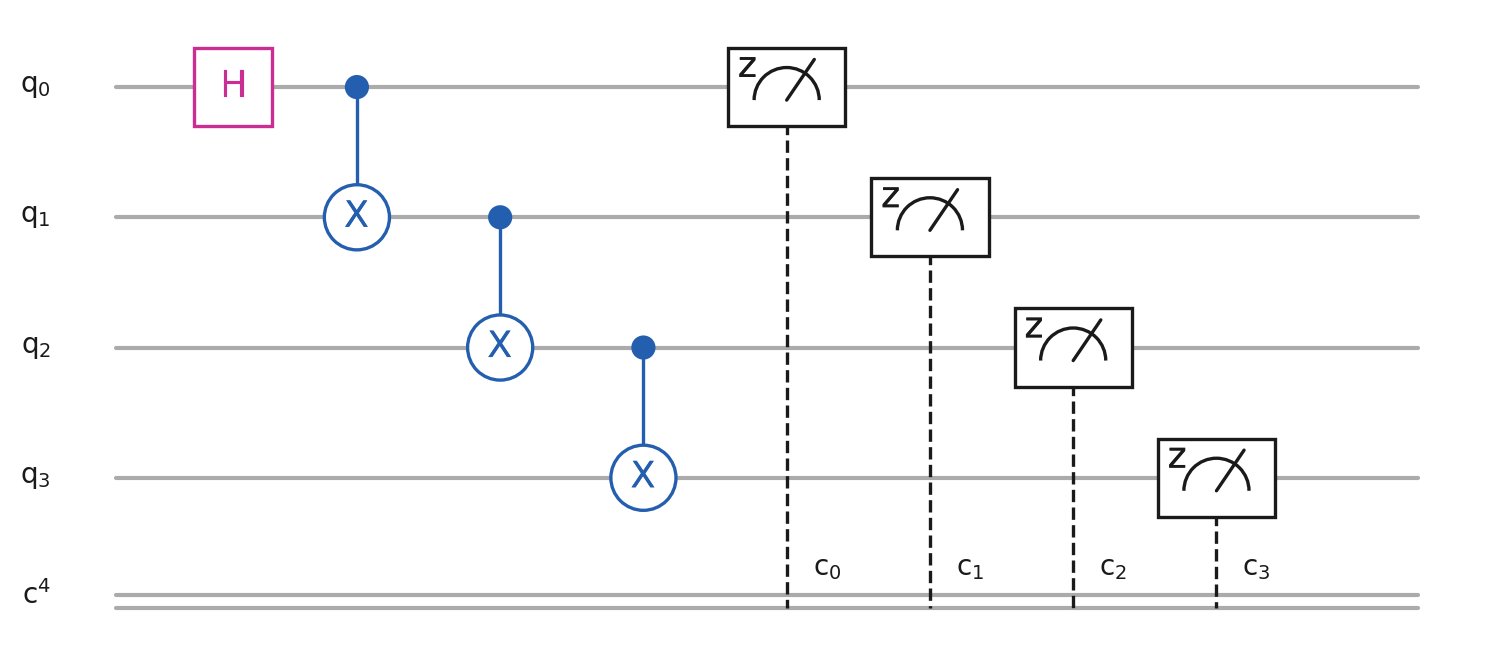

In [2]:
import numpy as np
from qpiai_quantum.state_preparation import GHZStateGenerator

ghz = GHZStateGenerator(num_qubits=4)
circuit = ghz.build_circuit(measure=True)
circuit.show()

### Execute on QpiAI Quantum Hardware

Now we'll execute the circuit and analyze the results:

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [3]:
shots = 10000
# Note: experiment_name is only required for cloud executions
result = circuit.run(shots=shots, device_name="QpiAI-QSV-Local")
print(f"Counts : {result.get_counts()}")

Counts : {'0000': 4917, '1111': 5083}


### Visualize Results

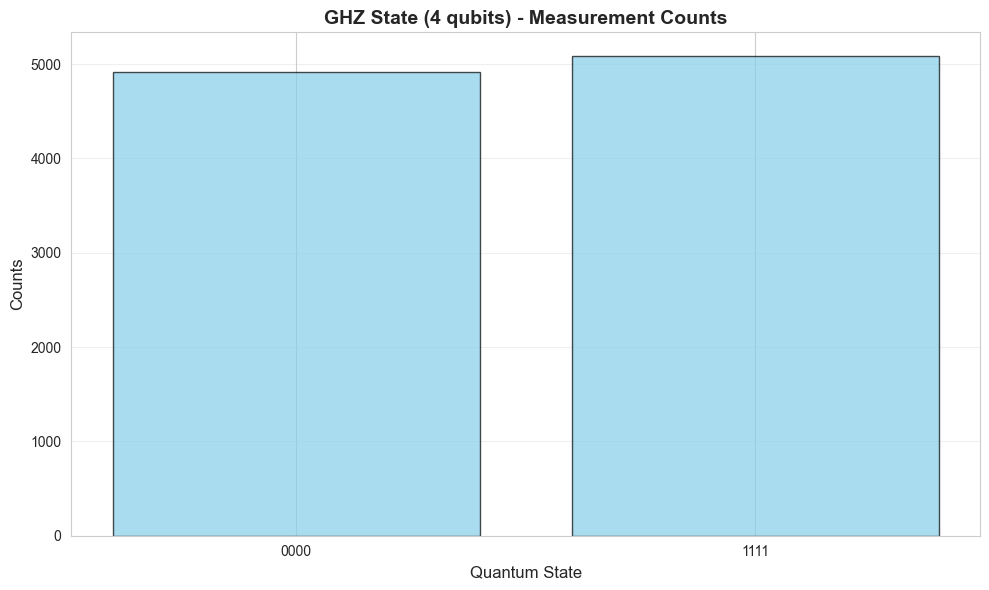

In [4]:
ghz.visualize('histogram', result=result)

### Get Expected Outcomes

In [5]:
expected = ghz.get_expected_outcomes()
print(f"Expected outcomes: {expected}")

Expected outcomes: {'0000': 0.5, '1111': 0.5}


## Part 2: Exploring Different GHZ State Sizes

One of the powerful features of GHZ states is the ability to scale to any number of qubits. Let's explore different sizes:

### 5-Qubit GHZ State

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


5-Qubit GHZ State Analysis


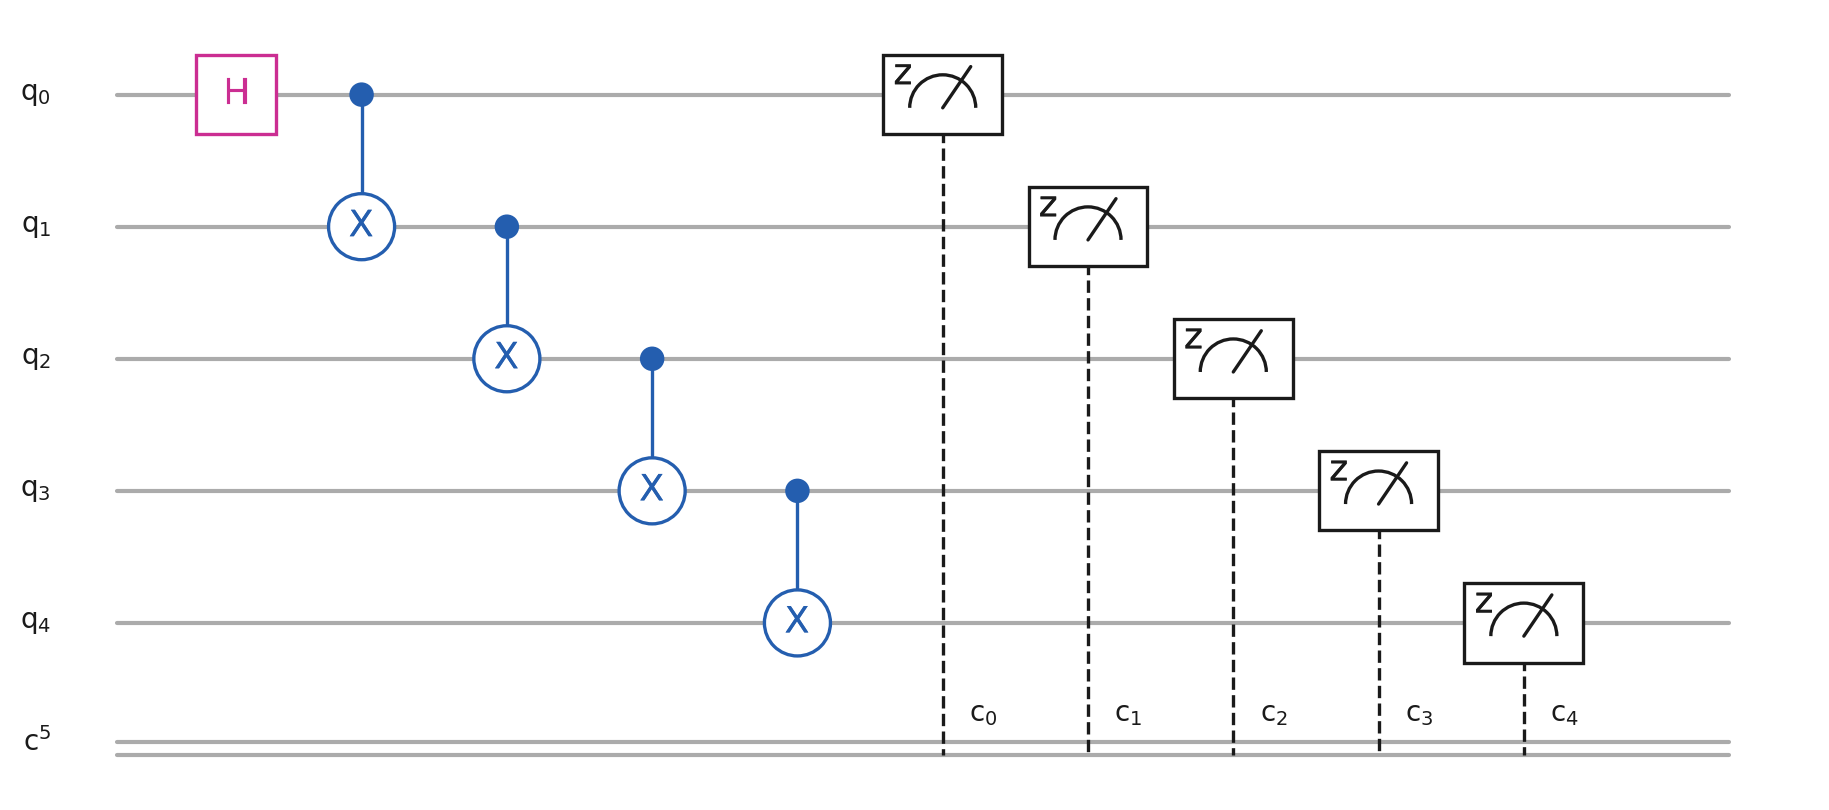


Expected outcomes: {'00000': 0.5, '11111': 0.5}
Measurement counts: {'00000': 2493, '11111': 2507}
Entanglement verified: True
Entanglement depth: 5
Circuit depth: 5


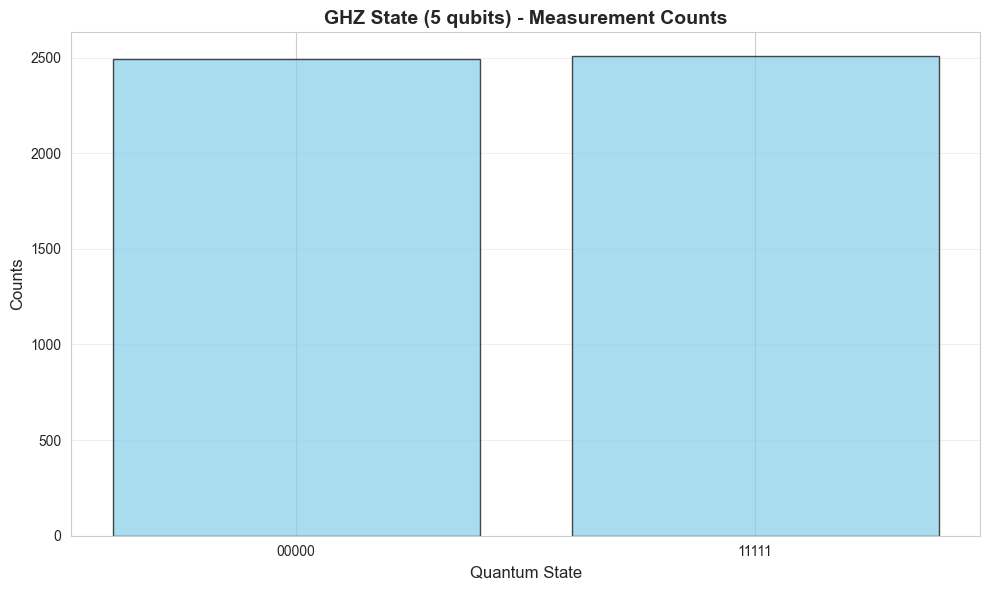

In [6]:
ghz_5 = GHZStateGenerator(num_qubits=5)
print("5-Qubit GHZ State Analysis")
print("="*60)

circuit_5 = ghz_5.build_circuit(measure=True)
circuit_5.show()

# Note: experiment_name is only required for cloud executions
result_5 = circuit_5.run(shots=5000, device_name="QpiAI-QSV-Local")

print(f"\nExpected outcomes: {ghz_5.get_expected_outcomes()}")
print(f"Measurement counts: {result_5.get_counts()}")
print(f"Entanglement verified: {ghz_5.verify_entanglement(result_5)}")
print(f"Entanglement depth: {ghz_5.calculate_entanglement_depth()}")
print(f"Circuit depth: {ghz_5.get_circuit_depth()}")

ghz_5.visualize('histogram', result=result_5)

## Summary and Key Takeaways

In this tutorial, we've comprehensively explored:


1. **GHZ State Fundamentals**: Multi-qubit maximally entangled states
2. **Circuit Construction**: Hadamard + CNOT chain architecture
3. **Scalability**: From 3 to 7+ qubits with linear scaling
4. **Size Comparison**: Systematic comparison across different qubit counts


### Key Differences: GHZ vs Bell States

| Property | Bell States | GHZ States |
|----------|-------------|------------|
| **Qubits** | 2 qubits only | 3+ qubits |
| **Outcomes** | 2 outcomes | 2 outcomes (always) |
| **Scalability** | Fixed at 2 qubits | Scales to any n ≥ 3 |
| **Applications** | Basic entanglement | Multi-party protocols |

### Key Methods Reference

- `GHZStateGenerator(num_qubits)` - Create GHZ state generator (min 3 qubits)
- `build_circuit(measure=True)` - Build the quantum circuit
- `run(shots, backend)` - Execute on quantum backend (Note: `experiment_name` is optional and only required for cloud executions)
- `get_expected_outcomes()` - Get theoretical distribution
---

**Thank you for learning with QpiAI!**

In [7]:
import qpiai_quantum
print(qpiai_quantum.__version__)

0.1.32
